In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import sys; sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/lib') # add library path

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from queue import PriorityQueue

from variable_print import p,ps,pst
from gridworld import GridworldEnv
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## `GridWorld` 초기화하기

`GridworldEnv`생성

In [ ]:
nx, ny = 4, 4
env = GridworldEnv([ny, nx])

## Incremental Monte-carlo Agent 생성  

`MCAgent`:  
>Monte-carlo policy evaluation 수행후   
>Action value evaluation 수행  
$$Q(s,a) \leftarrow Q(s,a) + \alpha (G(s,a) - Q(s,a))$$
>'$\epsilon$-greedy policy'부터 시작   

In [ ]:
import monte_carlo as mc

mc_agent = mc.MCAgent(gamma=1.0,  # Incremental MC policy evaluation
                   lr=1e-3,       # alpha
                   num_states=nx * ny,
                   num_actions=4,
                   epsilon=1.0)   # epsilon=1.0 : 100% random policy

### `run_episode()`

In [ ]:
def run_episode(env, agent, timeout=1000):
    env.reset()  # s <- random state
    states = []
    actions = []
    rewards = []
    i = done = 0
    while not(done or i>timeout): #episode가 끝나지 않는 경우 강제 종료
        state = env.s
        action = agent.get_action(state)
        next_state, reward, done, info = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        i += 1
    if done: # timeout은 epi.가 끝나지 않아 추산에서 제외
        episode = (states, actions, rewards)
        agent.update(episode) # Incremental MC policy evaluation: v(s),q(s,a) update

In [ ]:
%%time
for _ in range(5000):
    run_episode(env, mc_agent)

### `agent.get_action()`, `agent._policy_q`  
**policy evaluation과 policy improvement를 명확히 구분해서 구현**  
**일반적으로는 최신 Q(s,a)를 사용해서 정책을 실행함**
- improve_policy(): 명시적으로 policy 개선  
- get_action(): 개선된 policy에서 action을 얻음  
- `self._policy_q`: get_action에서 사용할 q,   
추산중에 사용하는 q와 분리하기 위해 사용   

```python
class VanillaMCAgent:
    def get_action(self, state):
        prob = np.random.uniform(0.0, 1.0, 1)
        if prob <= self.epsilon:  # random action(policy) 비율
            action = np.random.choice(range(self.num_actions))
        else:  # greedy policy
            action = self._policy_q[state, :].argmax()
        return action
    def improve_policy(self):
        self._policy_q = self.q.copy()
        #self.reset_statistics()
```

정책평가만 수행했기 때문에 아직 정책개선은 이루어 지지 않았음   
따라서 get_action은 random policy만 적용되고 있음  

In [ ]:
mc_agent._policy_q # 개선되지 않은 Q(s,a)

명시적 정책개선 수행

In [ ]:
## get_action(): action = self._policy_q[state, :].argmax() 이므로
## _policy_q table을 update하는 것이 policy update임
mc_agent.improve_policy() # self._policy_q = self.q.copy()

적용된 정책개선 확인

In [ ]:
mc_agent._policy_q # policy로 사용되는 Q(s,a)

추산된 q(s,a)값과 최대값을 시각화해 보자   

In [ ]:
import pandas as pd

def highlight_max(s):
    # highlight the maximum in a Series green.
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

def visualize_q(q):
    df = pd.DataFrame(q, columns=['up', 'right', 'down', 'left']).T
    df = df.style.apply(highlight_max)
    return df

In [ ]:
visualize_q(mc_agent.q)

### 현재까지 추산된 상태가치함수 $V(s)$ 및 행동가치함수$Q(s,a)$ 확인하기  
시각화한 policy는 greedy policy를 적용(max를선택)했을 때의 결과를 보여준것  

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(8,3))
visualize_value_function(ax[0], mc_agent.v, nx, ny)
_ = ax[0].set_title("Value pi")
visualize_policy(ax[1], mc_agent.q, nx, ny)
_ = ax[1].set_title("Greedy policy")

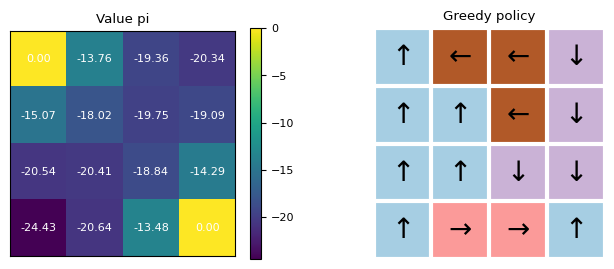

## $\epsilon$-greedy policy improvement  
epsilon 을 조금씩 줄이면서,  
최적 정책함수, 최적 상태가치함수, 최적 행동가치함수 찾아 보자  


```python
def decaying_epsilon(self, factor):
    self.epsilon *= factor
```

In [ ]:
def decaying_epsilon_and_run(agent, env,
                             decaying_factor:float,
                             n_runs:int = 5000):
    agent.reset_statistics()
    agent.decaying_epsilon(decaying_factor)
    print(f"epsilon : {agent.epsilon:0.6f}")

    for _ in range(n_runs):
        # 한번의 episode, agent.update(episode): v(s),q(s,a)update(Incremental MC)
        run_episode(env, agent)
    agent.improve_policy()

    fig, ax = plt.subplots(1,2, figsize=(8,3))
    visualize_value_function(ax[0], agent.v, nx, ny)
    _ = ax[0].set_title("Value pi")
    visualize_policy(ax[1], agent._policy_q, nx, ny)
    _ = ax[1].set_title("Greedy policy")

In [ ]:
mc_agent.epsilon= 1.0
mc_agent.reset() # v,q,_policy_q <- 0

### epsilon = epsilon * factor
factors = [1.0,1.0,1.0,1.0,1.0]  # case 1 : epsilon 유지
#factors = [0.5,1.0,1.0,1.0,1.0]  # case 2
#factors = [0.9,0.9,0.9,0.9,0.9]  # case 3
#factors = [0.9,0.9,0.1,0.1,0.1]  # case 4

for i,_ in enumerate(factors):
  decaying_epsilon_and_run(mc_agent, env, factors[i], n_runs=5000)

### **case 1** | **case 2**    
### **case 3** | **case 4**    


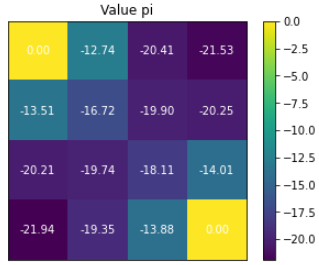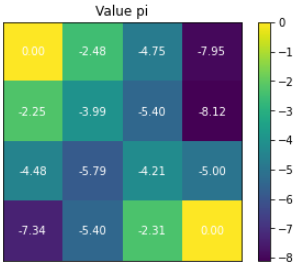 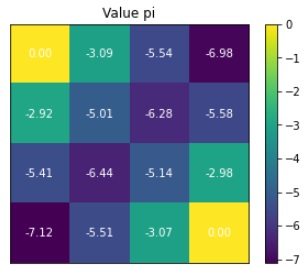 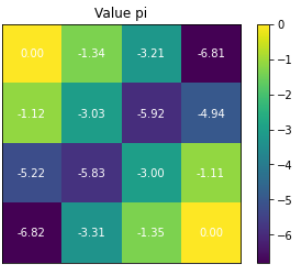

**DP로 찾았던 정답과 비교해 보자**

### 최적정책함수를 찾고, 이를 기준으로 최적 상태가치함수를 찾아 보자  
앞에서 진행과정을 보면  
 $\epsilon$ decaying 이전에 최적 정책함수를 찾은 것으로 보임(최적 상태가치함수는 찾지 못했어도..)    
그렇다면, 최정정책함수를 알고 있는 상태에서  
MC method를 반복해서 최적 상태가치함수를 찾을 수 있는지 확인해 보자  

1) 먼저 random policy에서 MC policy evaluation을 통해 최적 정책 함수를 찾아 놓자  

epsilon : 1.000000
CPU times: user 3.25 s, sys: 24.4 ms, total: 3.28 s
Wall time: 3.26 s


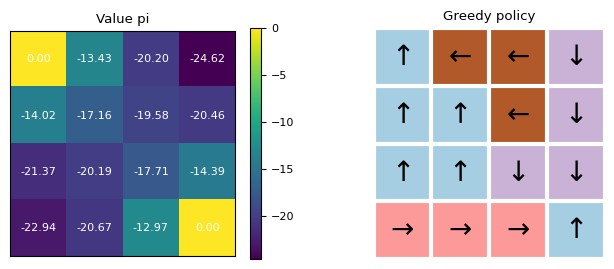

In [ ]:
%%time
mc_agent.epsilon= 1.0
mc_agent.reset()
# 마지막에 한번 정책개선 수행
decaying_epsilon_and_run(mc_agent, env, decaying_factor=1, n_runs=5000)
# Wall time: 3.26 s

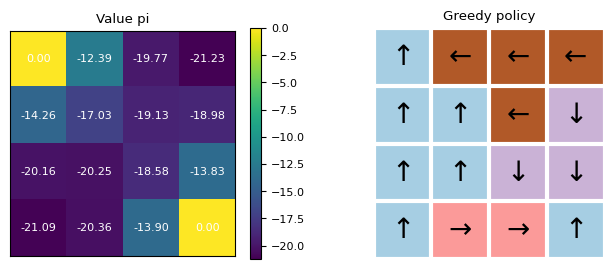

2) 최적정책을 찾았으니 정책개선 없이   
정책평가를 반복하여 최적 상태가치함수를 찾을 수 있는지 확인해 보자   

epsilon : 0.000000
CPU times: user 301 ms, sys: 2.89 ms, total: 304 ms
Wall time: 303 ms


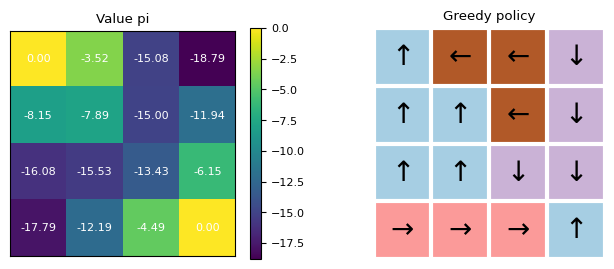

In [ ]:
%%time
# decaying_factor=0.0 으로 하여 random policy 확률 0%
# random ploicy가 적용되지 않으면 episode가 짧아짐(시행시간 단축)
# 정책개선은 마지막에 한번만 수행됨
decaying_epsilon_and_run(mc_agent, env, decaying_factor=0.0, n_runs=5000)#100000)
# Wall time: 303 ms

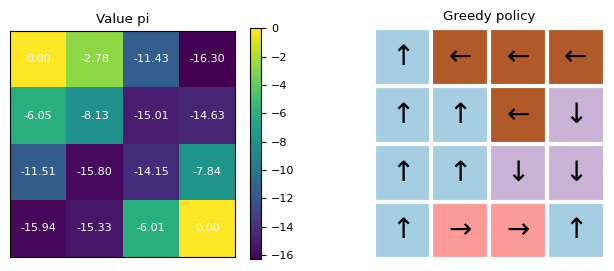

추가적으로 10000번 더

epsilon : 0.000000


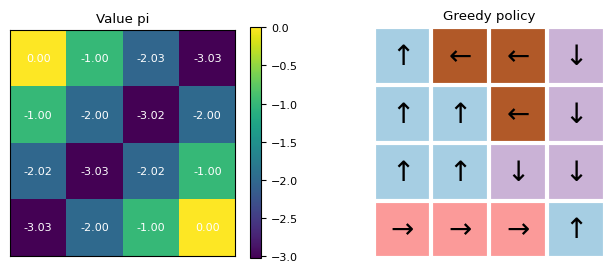

In [ ]:
decaying_epsilon_and_run(mc_agent, env, decaying_factor=0.0, n_runs=100000)

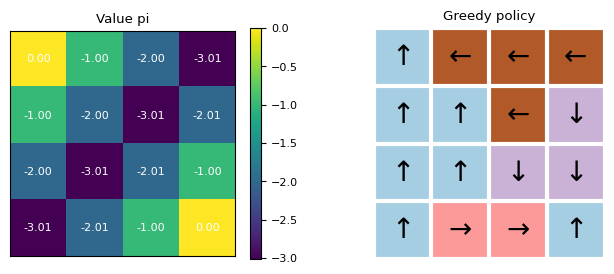

### 성급한 decaying
$\epsilon$-decay : 적당한 schedule이 필수  
그렇지 못하면, 최적정책을 찾지 못하게 됨


In [ ]:
%time
mc_agent.epsilon= 1.0
mc_agent.reset()
factors = [0.5, 0.1, 0.1, 0.0, 0.0]

for i,_ in enumerate(factors):
  decaying_epsilon_and_run(mc_agent, env, factors[i],n_runs=5000)